# Práctica 4 - Anatomía de un dataset de Machine Learning
**Sesión 4 - El dataset**

## Objetivos
Analizar un dataset desde el punto de vista de Machine Learning: muestras, variables, identificadores, características, target, \(X\), \(y\), tipos conceptuales, valores ausentes y distribuciones.

> El objetivo principal no es escribir mucho código, sino **interpretar correctamente los datos**.

## Contexto
Una plataforma de comercio electrónico dispone de información histórica sobre sus clientes. Trabajaremos con `clientes_ecommerce.csv`.

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador único |
| `edad` | Edad |
| `antiguedad_meses` | Meses desde el registro |
| `ingresos_anuales` | Ingresos anuales estimados |
| `gasto_mensual` | Gasto medio mensual |
| `num_compras` | Compras del último año |
| `devoluciones` | Devoluciones del último año |
| `dispositivo` | Dispositivo principal |
| `zona` | Zona de residencia |
| `nivel_fidelidad` | Bronce, Plata, Oro o Platino |
| `satisfaccion` | Valoración de 1 a 5 |
| `compra_proximo_mes` | Compra el mes siguiente: Sí/No |

Completa las celdas `# TODO` y responde en Markdown.

## Preparación

In [99]:
# TODO: importa NumPy, pandas y matplotlib.pyplot
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

# TODO: carga clientes_ecommerce.csv en df
df = pd.read_csv("clientes_ecommerce.csv")

## Parte 1 - Comprender el dataset
### Ejercicio 1 - Primera inspección
Muestra las primeras 10 filas.

In [100]:
# TODO: muestra las primeras 10 filas
df.head(10)

,cliente_id,edad,antiguedad_meses,ingresos_anuales,gasto_mensual,num_compras,devoluciones,dispositivo,zona,nivel_fidelidad,satisfaccion,compra_proximo_mes
0,20001,67,102.0,9000.00,60.73,7,3,Móvil,Oeste,Oro,5,No
1,20002,28,93.0,35683.86,131.74,6,1,Móvil,Este,Bronce,2,No
2,20003,19,87.0,37152.19,55.33,8,1,Ordenador,Este,Plata,5,Sí
3,20004,55,79.0,40158.29,24.33,7,0,Ordenador,Norte,Bronce,4,Sí
4,20005,39,3.0,27317.06,88.78,5,0,Móvil,Sur,Bronce,4,No
5,20006,45,25.0,32627.01,59.77,9,2,Móvil,Este,Bronce,5,No
6,20007,22,105.0,44101.68,109.67,8,0,Móvil,Norte,Oro,5,Sí
7,20008,39,90.0,44882.10,57.56,7,2,Ordenador,Norte,Plata,2,Sí
8,20009,55,56.0,55299.19,49.94,6,2,Móvil,Sur,Bronce,5,No
9,20010,38,93.0,9000.00,110.69,10,2,Ordenador,Centro,Oro,4,Sí


### Respuesta
1. ¿Qué representa una fila?
Un cliente
2. ¿Qué representa una columna?
Un atributo para esos clientes
3. ¿Cuál es la unidad de observación?
El cliente
4. ¿Todas las columnas son características? 
No, no hace falta, por ejemplo compra_proximo_mes no lo es



### Ejercicio 2 - Dimensiones
Obtén `df.shape`.

In [101]:
# TODO: consulta las dimensiones
df.shape

(400, 12)

### Respuesta
- Número de muestras:
400
- Número de columnas:
12
- ¿Tenemos el mismo número de características? ¿Por qué?

hay 12 columnas pero solo 10 características, porque cliente_id es identificador y compra_proximo_mes es el target.

## Parte 2 - Clasificación de variables
### Ejercicio 3 - Tipos almacenados

In [102]:
# TODO: consulta df.dtypes
df.dtypes


cliente_id              int64
edad                    int64
antiguedad_meses      float64
ingresos_anuales      float64
gasto_mensual         float64
num_compras             int64
devoluciones            int64
dispositivo               str
zona                      str
nivel_fidelidad           str
satisfaccion            int64
compra_proximo_mes        str
dtype: object

### Ficha de variables
Clasifica cada variable como: **Identificador, Numérica discreta, Numérica continua, Categórica nominal, Categórica ordinal o Target**.

| Variable | dtype | Tipo conceptual | ¿Feature candidata? |
|---|---|---|---|
| cliente_id | int64 | Identificador | No |
| edad | int64 | Numérica discreta | Sí |
| antiguedad_meses | float64 | Numérica discreta | Sí |
| ingresos_anuales | float64 | Numérica continua | Sí |
| gasto_mensual | float64 | Numérica continua | Sí |
| num_compras | int64 | Numérica discreta | Sí |
| devoluciones | int64 | Numérica discreta | Sí |
| dispositivo | str | Categórica nominal | Sí |
| zona | str | Categórica nominal | Sí |
| nivel_fidelidad | str | Categórica ordinal | Sí |
| satisfaccion | int64 | Categórica ordinal | Sí |
| compra_proximo_mes | str | Target | No |

No clasifiques únicamente por `dtype`.

### Ejercicio 4 - `cliente_id`
Muestra sus primeros 10 valores.

In [103]:
# TODO: analiza cliente_id
df["cliente_id"].head(10)

0    20001
1    20002
2    20003
3    20004
4    20005
5    20006
6    20007
7    20008
8    20009
9    20010
Name: cliente_id, dtype: int64

### Respuesta
1. ¿Qué dtype tiene?
int64
2. ¿Es por ello cuantitativa?
No
3. ¿Tiene sentido calcular su media?
No
4. ¿La incluirías inicialmente en \(X\)?
No
5. Justifica.
No la incluiría ya que no le aporta nada al modelo para aprender.


### Ejercicio 5 - `satisfaccion`
Muestra la frecuencia de sus valores ordenados.

In [104]:
# TODO: value_counts() + sort_index()
df["satisfaccion"].value_counts().sort_index()

satisfaccion
1     33
2     58
3    123
4    116
5     70
Name: count, dtype: int64

Sabemos que 1 = Muy insatisfecho, 2 = Insatisfecho, 3 = Neutral, 4 = Satisfecho y 5 = Muy satisfecho.

### Respuesta
1. ¿Cómo la almacena pandas?
Pandas la guarda como int64.

2. ¿Es simplemente numérica?
No. Los números 1–5 son etiquetas de categorías con orden
3. ¿Existe un orden?
Si,1 < 2 < 3 < 4 < 5 significa de menos a más satisfecho.
4. ¿Nominal u ordinal?
Ordinal
5. Explica `dtype` frente a significado conceptual.
Dtype sirve para ver que tipo de valor tiene cada clave


## Parte 3 - Calidad de los datos
### Ejercicio 6 - Información estructural

In [105]:
# TODO: utiliza df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          400 non-null    int64  
 1   edad                400 non-null    int64  
 2   antiguedad_meses    395 non-null    float64
 3   ingresos_anuales    396 non-null    float64
 4   gasto_mensual       397 non-null    float64
 5   num_compras         400 non-null    int64  
 6   devoluciones        400 non-null    int64  
 7   dispositivo         400 non-null    str    
 8   zona                400 non-null    str    
 9   nivel_fidelidad     400 non-null    str    
 10  satisfaccion        400 non-null    int64  
 11  compra_proximo_mes  400 non-null    str    
dtypes: float64(3), int64(5), str(4)
memory usage: 37.6 KB


### Respuesta
1. ¿Cuántas muestras hay?
400
2. ¿Qué tipos técnicos aparecen?
int(5), float(3) y str(4)
3. ¿Todas las columnas tienen los mismos valores no nulos?
No, hay algunas que les faltan algunas, como por ejemplo ingresos_anuales
4. ¿Qué columnas contienen ausentes?
ingresos_anuales, antiguedad_meses, gasto_mensual
5. ¿Cuántos faltan?
12


### Ejercicio 7 - Valores ausentes
Calcula cantidad y porcentaje por columna.

In [106]:
# TODO: valores ausentes por columna
print(f" la suma es:\n {df.isnull().sum()}")

# TODO: porcentaje de ausentes por columna
df.isnull().mean() * 100


 la suma es:
 cliente_id            0
edad                  0
antiguedad_meses      5
ingresos_anuales      4
gasto_mensual         3
num_compras           0
devoluciones          0
dispositivo           0
zona                  0
nivel_fidelidad       0
satisfaccion          0
compra_proximo_mes    0
dtype: int64


cliente_id            0.00
edad                  0.00
antiguedad_meses      1.25
ingresos_anuales      1.00
gasto_mensual         0.75
num_compras           0.00
devoluciones          0.00
dispositivo           0.00
zona                  0.00
nivel_fidelidad       0.00
satisfaccion          0.00
compra_proximo_mes    0.00
dtype: float64

### Reflexión
¿Es lo mismo que falten 5 valores entre 50 muestras que entre 100.000? ¿Por qué son útiles los porcentajes?
No, ya que 5 valores entre 50 puede alterar mas los datos que por 100.000 ya que en proporcion es mas importe esos 5 valores


## Parte 4 - Construcción de X e y
Queremos predecir: **¿realizará el cliente una compra el próximo mes?**

### Ejercicio 8 - Variable objetivo

In [107]:
# TODO: crea y
y = df["compra_proximo_mes"]
# TODO: muestra y.head() y y.shape
print(y.head())
y.shape

0    No
1    No
2    Sí
3    Sí
4    No
Name: compra_proximo_mes, dtype: str


(400,)

### Respuesta
1. ¿Qué representa cada elemento de \(y\)?
Si el cliente realizó una compra o no
2. ¿Cuántos contiene?
400
3. ¿Por qué el target no debe incluirse también en \(X\)?
Pq el modelo estaría viendo la respuesta y aprendería solo a copiarla 


### Ejercicio 9 - Construir \(X\)
Usa: `edad`, `antiguedad_meses`, `ingresos_anuales`, `gasto_mensual`, `num_compras`, `devoluciones`, `dispositivo`, `zona`, `nivel_fidelidad`, `satisfaccion`.

No incluyas `cliente_id` ni `compra_proximo_mes`.

In [108]:
# TODO: crea X
X = df[["edad", "antiguedad_meses", "ingresos_anuales", "gasto_mensual", "num_compras", "devoluciones", "dispositivo", "zona", "nivel_fidelidad", "satisfaccion"]]
# TODO: muestra X.head() y X.shape
display(X.head())
X.shape

,edad,antiguedad_meses,ingresos_anuales,gasto_mensual,num_compras,devoluciones,dispositivo,zona,nivel_fidelidad,satisfaccion
0,67,102.0,9000.00,60.73,7,3,Móvil,Oeste,Oro,5
1,28,93.0,35683.86,131.74,6,1,Móvil,Este,Bronce,2
2,19,87.0,37152.19,55.33,8,1,Ordenador,Este,Plata,5
3,55,79.0,40158.29,24.33,7,0,Ordenador,Norte,Bronce,4
4,39,3.0,27317.06,88.78,5,0,Móvil,Sur,Bronce,4


(400, 10)

### Ejercicio 10 - Dimensiones
Completa y explica:

- \(n =\) 400
- \(p =\) 10
- \(X.shape =\) 400,10
- \(y.shape =\) 400,

## Parte 5 - ¿Está etiquetado?
### Ejercicio 11
1. ¿Tenemos \(X\)?
si
2. ¿Tenemos \(y\)?
si
3. ¿Está etiquetado?
si
4. ¿Puede usarse para aprendizaje supervisado?
Si
5. ¿Qué tipo de problema es predecir `compra_proximo_mes`?
es un problema de clasificación, binario, supervisado ya que tienes todas las etiquetas
6. ¿Binario o multiclase?
Binario por que puede ser o si o no
7. ¿Cuáles son las clases?
Si y no


## Parte 6 - Distribuciones
### Ejercicio 12 - Variables categóricas
Analiza `dispositivo`, `zona`, `nivel_fidelidad` y `compra_proximo_mes` con frecuencias absolutas y relativas.

In [109]:
# TODO: value_counts() y value_counts(normalize=True) para las cuatro variables
for col in ["dispositivo", "zona", "nivel_fidelidad", "compra_proximo_mes"]:
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True) * 100)
    print()


dispositivo
Móvil        242
Ordenador    133
Tablet        25
Name: count, dtype: int64
dispositivo
Móvil        60.50
Ordenador    33.25
Tablet        6.25
Name: proportion, dtype: float64

zona
Este      89
Sur       80
Norte     79
Oeste     76
Centro    76
Name: count, dtype: int64
zona
Este      22.25
Sur       20.00
Norte     19.75
Oeste     19.00
Centro    19.00
Name: proportion, dtype: float64

nivel_fidelidad
Bronce     162
Plata      105
Oro         83
Platino     50
Name: count, dtype: int64
nivel_fidelidad
Bronce     40.50
Plata      26.25
Oro        20.75
Platino    12.50
Name: proportion, dtype: float64

compra_proximo_mes
No    246
Sí    154
Name: count, dtype: int64
compra_proximo_mes
No    61.5
Sí    38.5
Name: proportion, dtype: float64



### Tabla resumen
| Variable | Categoría más frecuente | Frecuencia | Porcentaje |
|---|---|---:|---:|
| dispositivo | Móvil | 242 | 60,50 % |
| zona | Este | 89 | 22,25 % |
| nivel_fidelidad | Bronce | 162 | 40,50 % |
| compra_proximo_mes | No | 246 | 61,50 % |

### Ejercicio 13 - Visualización del target
Crea un gráfico de barras con título y etiquetas.

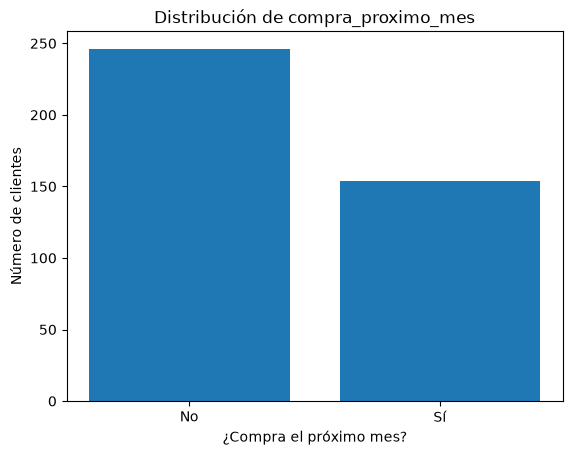

In [110]:
# TODO: gráfico de barras
conteo = df["compra_proximo_mes"].value_counts()

plt.bar(conteo.index, conteo.values)
plt.title("Distribución de compra_proximo_mes")
plt.xlabel("¿Compra el próximo mes?")
plt.ylabel("Número de clientes")
plt.show()


### Interpretación
¿Las clases aparecen aproximadamente con la misma frecuencia? 
No. 246 clientes (61,5 %) no compran el mes siguiente frente a 154 (38,5 %) que sí compran, así que la clase "No" es bastante más frecuente y las clases están desbalanceadas.

## Parte 7 - Variables numéricas
### Ejercicio 14 - Estadística descriptiva
Analiza `edad`, `ingresos_anuales`, `gasto_mensual`, `num_compras` y `devoluciones`.

In [111]:
# TODO: describe() solo sobre las columnas indicadas
df[["edad", "ingresos_anuales", "gasto_mensual","num_compras","devoluciones"]].describe()

,edad,ingresos_anuales,gasto_mensual,num_compras,devoluciones
count,400.000000,396.000000,397.000000,400.000000,400.000000
mean,46.402500,36440.920379,69.089320,8.225000,1.225000
std,18.007809,14325.228166,39.023238,2.780955,1.136929
min,18.000000,9000.000000,5.770000,2.000000,0.000000
25%,33.000000,26034.092500,39.720000,6.000000,0.000000
50%,45.000000,36817.275000,61.170000,8.000000,1.000000
75%,59.000000,45969.032500,90.150000,10.000000,2.000000
max,195.000000,82925.370000,260.000000,17.000000,5.000000


### Interpretación
Escribe una conclusión breve para cada variable:
- **edad:** media de 46 años y mediana de 45, con la mitad de los clientes entre 33 y 59 años. El máximo de **195 años es imposible**: es un error de datos.
- **ingresos_anuales:** media ≈ 36.400 € y mediana ≈ 36.800 €, por lo que la distribución es bastante simétrica. Hay 4 ausentes y el mínimo de 9.000 € se repite en 16 clientes, lo que podría indicar un valor límite o de relleno.
- **gasto_mensual:** media de 69 € frente a una mediana de 61 €. Hay algunos clientes con gasto alto (máximo de 260 €) que suben la media: asimetría a la derecha. Tiene 3 ausentes.
- **num_compras:** unas 8 compras al año de media, entre 2 y 17. Media y mediana coinciden, así que la distribución es equilibrada y sin valores extraños.
- **devoluciones:** pocas, con 1,2 de media y entre 0 y 5. Al menos el 25 % de los clientes no ha devuelto nada.

### Ejercicio 15 - Detectar algo sospechoso
1. ¿Hay algún valor poco razonable?
El de la edad, por el valor de la persona con 195 años
2. ¿En qué variable?
edad
3. ¿Por qué es sospechoso?
Por que es imposible que alguien tenga esa edad 
4. ¿Lo eliminarías inmediatamente?
No
5. ¿Qué comprobarías antes?
Comprobaría el porque de ese fallo



## Parte 8 - Distribuciones numéricas
### Ejercicio 16
Crea histogramas independientes de `edad`, `ingresos_anuales`, `gasto_mensual` y `num_compras`.

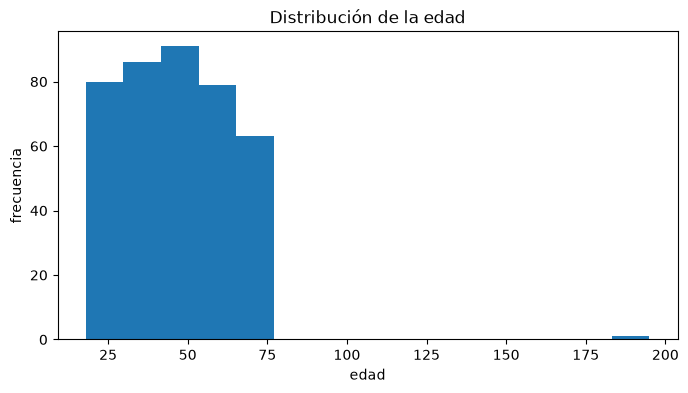

In [112]:
# TODO: histograma de edad
plt.figure(figsize=(8,4))
plt.hist(df["edad"],bins=15)
plt.title("Distribución de la edad")
plt.xlabel("edad")
plt.ylabel("frecuencia")
plt.show()

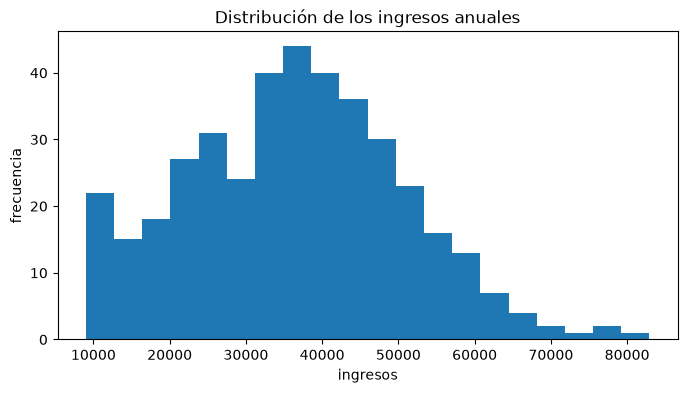

In [113]:
# TODO: histograma de ingresos_anuales
plt.figure(figsize=(8,4))
plt.hist(df["ingresos_anuales"], bins=20)
plt.title("Distribución de los ingresos anuales")
plt.xlabel("ingresos")
plt.ylabel("frecuencia")
plt.show()

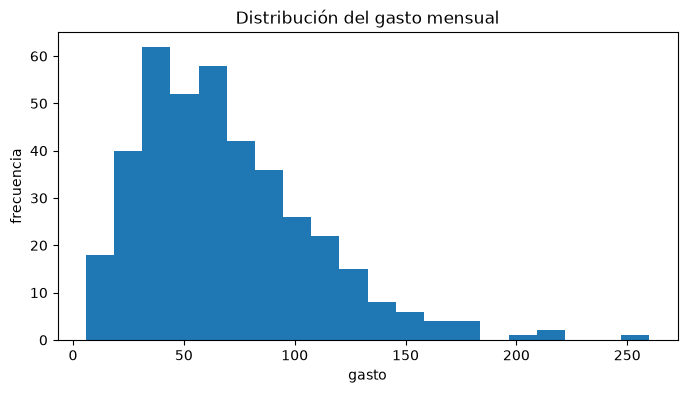

In [114]:
# TODO: histograma de gasto_mensual
plt.figure(figsize=(8,4))
plt.hist(df["gasto_mensual"], bins=20)
plt.title("Distribución del gasto mensual")
plt.xlabel("gasto")
plt.ylabel("frecuencia")
plt.show()

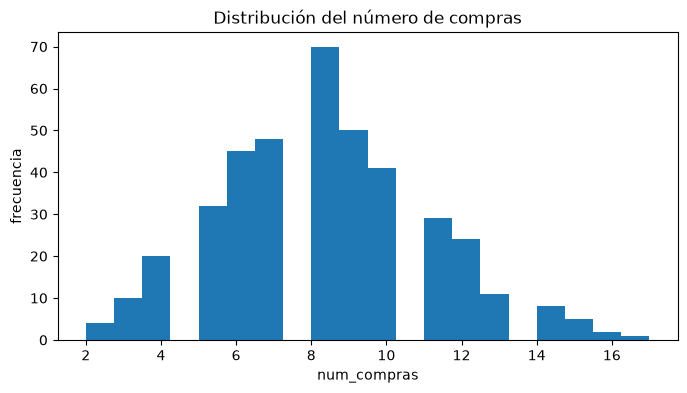

In [115]:
# TODO: histograma de num_compras
plt.figure(figsize=(8,4))
plt.hist(df["num_compras"], bins=20)
plt.title("Distribución del número de compras")
plt.xlabel("num_compras")
plt.ylabel("frecuencia")
plt.show()

### Observaciones
- **edad:** en la edad hay un outlier, en la edad, pero por lo demás está todo bien repartido
- **ingresos_anuales:** En los ingresos hay una asimetria positiva, se puede ver por que la cola baja hacia la derecha
- **gasto_mensual:**En el gasto mensual pasa lo mismo que en la edad, regresion positiva, además podria haber dos outliers entre los valores 200 y 250 
- **num_compras:** El histograma tiene una distribucion simétrica en forma de campana

## Parte 9 - Un mismo dataset, diferentes problemas
### Ejercicio 17 - Problema A
> ¿Realizará el cliente una compra el próximo mes?

Completa y justifica:
- Target: compra_proximo_mes
- ¿Existe \(y\)?: Si
- Supervisado / no supervisado: Supervisado
- Clasificación / regresión / clustering: Clasificación 
- Binaria / multiclase: Binaria

### Ejercicio 18 - Problema B
Supón una columna `gasto_proximo_mes` con cantidades monetarias.

> ¿Cuánto gastará el cliente el próximo mes?

1. ¿Cuál sería \(y\)? Compra_proximo_mes
2. ¿Qué tipo de variable? Booleana
3. ¿Supervisado? Si
4. ¿Clasificación o regresión? Clasificacion
5. ¿Por qué? Porque clasificaria en si alguien va a gastar el siguiente mes o no

**Respuesta:** Escribe aquí.

### Ejercicio 19 - Problema C
> Descubrir grupos de clientes similares sin grupos definidos previamente.

1. ¿Existe etiqueta de grupo? No
2. ¿Necesitamos \(y\)? No
3. ¿Supervisado o no supervisado? No supervisado
4. ¿Qué técnica usaríamos? Clustering
5. ¿Qué variables podrían describir los grupos? Podriamos usar, la edad, la zona, la antiguedad, los ingresos y el gasto mensual ya que son los valores que se podria usar para agrupar a las personas

**Respuesta:** Escribe aquí.

## Parte 10 - Razonamiento
### Ejercicio 20 - ¿Una columna puede cambiar de papel?
¿Por qué una misma variable puede actuar como característica en un problema y como objetivo en otro?
Por que depende del contexto en el que se usa ese dato, los datos se pueden usar para muchos objetivos
**Respuesta:** Escribe aquí.

### Ejercicio 21 - ¿Qué está mal aquí?
Un compañero hace:

```python
X = df.drop(columns=["compra_proximo_mes"])
y = df["compra_proximo_mes"]
```

y afirma que todas las columnas de `X` ya son características adecuadas.

¿Estás de acuerdo? Identifica al menos dos cuestiones que revisarías.
No, por ejemplo Cliente_id no le serviría para util ya que es un identificador y luego no ha limpiado los datos con outliers como el de edad 


## Parte 11 - Ficha técnica
### Ejercicio 22

```text
FICHA DEL DATASET
=================
Nombre: Clientes e-commerce
Número de muestras:400
Número de columnas:12
Unidad de observación: El cliente
Identificador:cliente_id
Target: compra_proximo_mes
Tipo de target: binario, para ver si compra o no compra el proximo mes
Número de features candidatas: 10
Features numéricas: 6 
Features categóricas nominales: 2
Features ordinales: 2
Datos etiquetados: Si
Valores ausentes: 12
Problema principal: Predecir si un cliente comprará el próximo mes
Tipo de aprendizaje: Supervisado
Tipo de tarea:Clasificación binaria
```

In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          400 non-null    int64  
 1   edad                400 non-null    int64  
 2   antiguedad_meses    395 non-null    float64
 3   ingresos_anuales    396 non-null    float64
 4   gasto_mensual       397 non-null    float64
 5   num_compras         400 non-null    int64  
 6   devoluciones        400 non-null    int64  
 7   dispositivo         400 non-null    str    
 8   zona                400 non-null    str    
 9   nivel_fidelidad     400 non-null    str    
 10  satisfaccion        400 non-null    int64  
 11  compra_proximo_mes  400 non-null    str    
dtypes: float64(3), int64(5), str(4)
memory usage: 37.6 KB


## Parte 12 - Conclusiones
### Ejercicio 23
Escribe entre **10 y 15 líneas** incluyendo: muestra, dimensiones, columnas vs. features, identificador, tipos de variables, target, \(X\), \(y\), etiquetado, ausentes, distribuciones, posible problema de calidad y tipo de problema de ML.

### Conclusiones
El dataset tiene 400 muestras, una por cliente, y 12 columnas.
De ellas, solo 10 son features: cliente_id es un identificador y compra_proximo_mes es el target.
Hay 6 variables numéricas, 2 categóricas nominales y 2 ordinales.
Satisfaccion se guarda como número, pero conceptualmente es ordinal.
X tiene forma (400, 10) e y tiene forma (400,).
El dataset está etiquetado, porque todos los clientes tienen el target informado.
Hay 12 valores ausentes en antigüedad, ingresos y gasto, menos del 1,5 % por columna.
El target está desbalanceado: 61,5 % "No" frente a 38,5 % "Sí".
num_compras es simétrica y gasto_mensual tiene asimetría a la derecha.
Como problema de calidad destaca una edad de 195 años, claramente errónea.
Antes de entrenar habría que tratar ausentes y outliers y codificar las categóricas.
Es un problema de aprendizaje supervisado de clasificación binaria.



# Ampliación opcional - El reto del analista
Mediante pandas, responde e interpreta:

1. ¿Qué nivel de fidelidad presenta mayor gasto mensual medio?
2. ¿El gasto histórico medio difiere entre quienes compran el mes siguiente y quienes no?
3. ¿Qué dispositivo tiene mayor número medio de compras?
4. ¿Cuál es la satisfacción media por nivel de fidelidad?
5. ¿Qué porcentaje de clientes de cada nivel compra el mes siguiente?

> Una asociación no demuestra causalidad.

In [117]:
# TODO: ampliación opcional
# 1. Gasto mensual medio por nivel de fidelidad
print(df.groupby("nivel_fidelidad")["gasto_mensual"].mean().sort_values(ascending=False), "\n")

# 2. Gasto medio según si compra el mes siguiente
print(df.groupby("compra_proximo_mes")["gasto_mensual"].mean(), "\n")

# 3. Número medio de compras por dispositivo
print(df.groupby("dispositivo")["num_compras"].mean().sort_values(ascending=False), "\n")

# 4. Satisfacción media por nivel de fidelidad
print(df.groupby("nivel_fidelidad")["satisfaccion"].mean(), "\n")

# 5. % de clientes de cada nivel que compra el mes siguiente
print((df["compra_proximo_mes"] == "Sí").groupby(df["nivel_fidelidad"]).mean() * 100)

nivel_fidelidad
Oro        70.932410
Platino    69.700400
Plata      68.686095
Bronce     68.201321
Name: gasto_mensual, dtype: float64 

compra_proximo_mes
No    64.589469
Sí    76.342368
Name: gasto_mensual, dtype: float64 

dispositivo
Ordenador    8.240602
Tablet       8.240000
Móvil        8.214876
Name: num_compras, dtype: float64 

nivel_fidelidad
Bronce     3.308642
Oro        3.373494
Plata      3.371429
Platino    3.240000
Name: satisfaccion, dtype: float64 

nivel_fidelidad
Bronce     30.864198
Oro        37.349398
Plata      40.000000
Platino    62.000000
Name: compra_proximo_mes, dtype: float64


# Antes de entregar
- Completa todos los `TODO`.
- Responde las preguntas en Markdown.
- Añade títulos y etiquetas a los gráficos.
- Ejecuta el notebook completo desde el principio y comprueba que no hay errores.
- Justifica tus decisiones.

**Nombre recomendado:** `Practica_04_Apellido_Nombre.ipynb`